<h4>This is a trial Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df_breakdown = pd.read_csv('/Users/samarth/Documents/SIH 26/final_syb/Breakdown_ALL.csv')
df_breakdown.isnull().sum()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/samarth/Documents/SIH 26/final_syb/Breakdown_ALL.csv'

In [ ]:
df_breakdown.duplicated().sum()


np.int64(5)

In [ ]:
df_breakdown["time"] = pd.timedelta_range(
    start="0 min",
    periods=len(df_breakdown),
    freq="30min"
)

df_breakdown["time"] = df_breakdown["time"].astype(str)
df_breakdown.head()

,Voltage,Current,time
0,545.2415,0.000010,0 days 00:00:00
1,550.5257,0.000004,0 days 00:30:00
2,551.0267,0.000004,0 days 01:00:00
3,551.5286,0.000004,0 days 01:30:00
4,552.0283,0.000004,0 days 02:00:00


In [ ]:
df_breakdown.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  1800 non-null   float64
 1   Current  1800 non-null   float64
 2   time     1800 non-null   str    
dtypes: float64(2), str(1)
memory usage: 42.3 KB


In [3]:
X = df_breakdown["Voltage"]
y = df_breakdown["Current"]

NameError: name 'df_breakdown' is not defined

<Axes: xlabel='Collector_Emitter_Voltage_Vce', ylabel='Leakage_Current_Ic'>

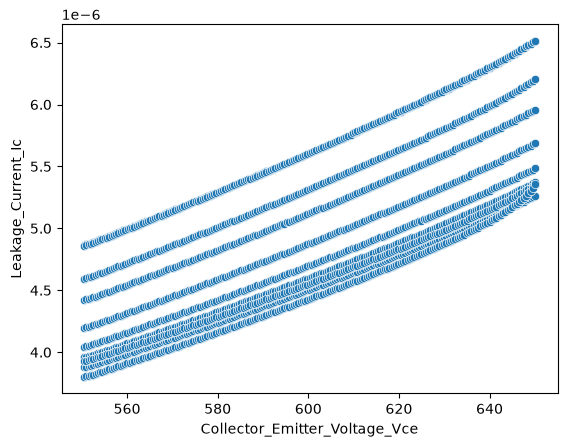

In [ ]:
sns.scatterplot(x=X, y=y)

In [ ]:
# sns.heatmap(df_breakdown.corr(), annot=True, cmap='Blues')

<Axes: xlabel='Collector_Emitter_Voltage_Vce', ylabel='Leakage_Current_Ic'>

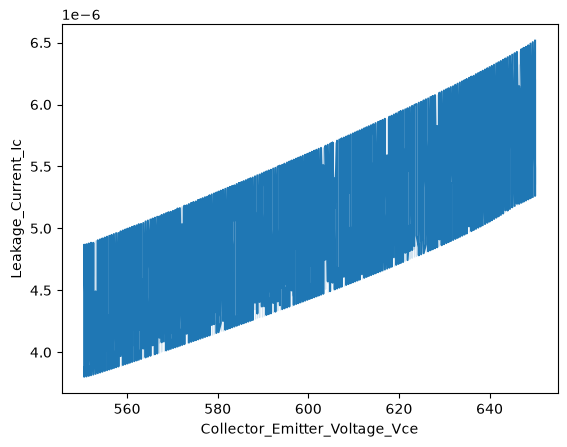

In [ ]:
sns.lineplot(x = X, y = y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train.values.reshape(-1, 1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.995e-06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1151.38]


In [ ]:
y_pred = model.predict(X_test.values.reshape(-1, 1))

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
mean_squared_error = mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

print("Mean Squared Error:", mean_squared_error)
print("R-squared Score:", r2_score)

Mean Squared Error: 1.9172904827504455e-13
R-squared Score: 0.4943038032288445
